In [46]:
# !pip install scikit-learn

In [47]:
from torchvision.transforms.v2 import RandomRotation, RandomPhotometricDistort, \
RandomHorizontalFlip, RandomVerticalFlip, Compose
from torchvision.transforms import ToTensor, Normalize
from torchvision.datasets import FashionMNIST
from torch.utils.data import DataLoader
from matplotlib import pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torchsummary import summary
from sklearn.metrics import classification_report

In [9]:
# Предобработка и аугментация для обучающего датасета
train_transforms = Compose([
    RandomHorizontalFlip(p=0.2),
    RandomVerticalFlip(p=0.2),
    RandomRotation([-5, 5]),
    ToTensor(),
    Normalize((0.5), (0.5))
])

# Предобработка для проверочного датасета
test_transforms = Compose([
    ToTensor(),
    Normalize((0.5), (0.5))
])

In [10]:
train_dataset = FashionMNIST(root ='data/', # куда скачать
                             download=True, 
                             transform=train_transforms, 
                             train=True)
val_dataset = FashionMNIST(root ='data/',
                           download=True, 
                           transform=test_transforms,
                           train=False)

print("Количество изображений в train:", len(train_dataset))
print("Количество изображений в val:", len(val_dataset))

Количество изображений в train: 60000
Количество изображений в val: 10000


In [13]:
batch_size = 16
train_loader = DataLoader(train_dataset,
                          batch_size=batch_size,
                          shuffle=True)
val_loader = DataLoader(val_dataset,
                        batch_size=batch_size,
                        shuffle=False)

T-shirt/top
T-shirt/top
Dress
T-shirt/top
Pullover
Sneaker
Pullover
Sandal
Sandal
T-shirt/top


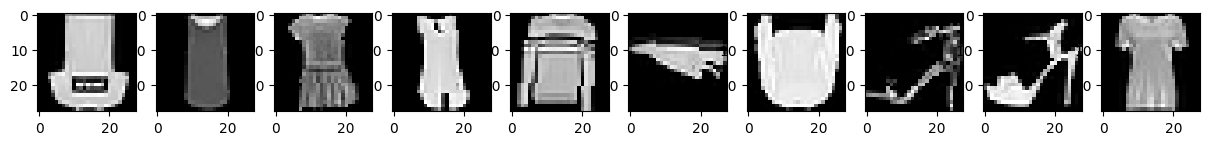

In [14]:
# Названия классов из датасета
classes = ('T-shirt/top', 'Trouser', 'Pullover', 'Dress',
           'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot')

fig = plt.figure(figsize=(15,5))
for index in range (1, 11):
    image, label = train_dataset[index]
    print(classes[label])
    plt.subplot(1, 10, index)
    plt.imshow(image[0], cmap='gray')

In [34]:
class FashionClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, padding='same')
        self.bn1 = nn.BatchNorm2d(32)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(32, 64, 3, padding='same')
        self.bn2 = nn.BatchNorm2d(64)
        self.avgpool = nn.AdaptiveAvgPool2d(1)
        self.flatten = nn.Flatten()
        self.fc = nn.Linear(64, 10)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.pool(x)

        x = self.conv2(x)
        x = self.bn2(x)
        x = self.relu(x)
        x = self.pool(x)

        x = self.avgpool(x)
        x = self.flatten(x)
        x = self.fc(x)
        return x

model = FashionClassifier()
summary(model, input_size=(1, 28, 28))
# x = torch.randn(1, 1, 28, 28)
# out = model(x)
# out.shape

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 28, 28]             320
       BatchNorm2d-2           [-1, 32, 28, 28]              64
              ReLU-3           [-1, 32, 28, 28]               0
         MaxPool2d-4           [-1, 32, 14, 14]               0
            Conv2d-5           [-1, 64, 14, 14]          18,496
       BatchNorm2d-6           [-1, 64, 14, 14]             128
              ReLU-7           [-1, 64, 14, 14]               0
         MaxPool2d-8             [-1, 64, 7, 7]               0
 AdaptiveAvgPool2d-9             [-1, 64, 1, 1]               0
          Flatten-10                   [-1, 64]               0
           Linear-11                   [-1, 10]             650
Total params: 19,658
Trainable params: 19,658
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/ba

In [35]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

In [40]:
def train_one_epoch(epoch_index):
    running_loss = 0.
    last_loss = 0.

    for batch_index, data in enumerate(train_loader):
        # Извлечение батча
        inputs, labels = data
        # Обнуление градиентов
        optimizer.zero_grad()
        # Прямое распространение
        outputs = model(inputs)
        # Подсчёт ошибки
        loss = criterion(outputs, labels)
        # Обратное распространение
        loss.backward()
        # Обновление весов
        optimizer.step()

        # Суммирование ошибки за последние 1000 батчей
        running_loss += loss.item()
        if batch_index % 1000 == 999:
            last_loss = running_loss / 1000. # средняя ошибка за 1000 батчей
            print(f'Эпоха: {epoch_index}, батч: {batch_index}, ошибка {last_loss}')
            running_loss = 0.

    return last_loss

In [41]:
EPOCHS = 10

best_vloss = 1e5

for epoch in range(EPOCHS):
    print(f'Эпоха {epoch}')

    # Перевод модели в режим обучения
    model.train(True)
    # Эпоха обучения
    avg_loss = train_one_epoch(epoch)

    # Перевод модели в режим валидации
    model.eval()
    running_vloss = 0.0

    # Валидация
    with torch.no_grad():
        for i, vdata in enumerate(val_loader):
            vinputs, vlabels = vdata
            voutputs = model(vinputs)
            vloss = criterion(voutputs, vlabels)
            running_vloss += vloss

    avg_vloss = running_vloss / (i + 1)

    # Сохранение лучшей модели
    if avg_vloss < best_vloss:
        best_vloss = avg_vloss
        model_path = f'models/fashion_classifier_{epoch}.pt'
        torch.save(model.state_dict(), model_path)

    print(f'В конце эпохи ошибка train {avg_loss}, ошибка val {avg_vloss}')

Эпоха 0
Эпоха: 0, батч: 999, ошибка 0.4334465443901718
Эпоха: 0, батч: 1999, ошибка 0.42584090952575204
Эпоха: 0, батч: 2999, ошибка 0.4213893995210528
В конце эпохи ошибка train 0.4213893995210528, ошибка val 0.3838764429092407
Эпоха 1
Эпоха: 1, батч: 999, ошибка 0.4198593535758555
Эпоха: 1, батч: 1999, ошибка 0.4046481770798564
Эпоха: 1, батч: 2999, ошибка 0.4164449113346636
В конце эпохи ошибка train 0.4164449113346636, ошибка val 0.36414241790771484
Эпоха 2
Эпоха: 2, батч: 999, ошибка 0.3990660828948021
Эпоха: 2, батч: 1999, ошибка 0.3931938418354839
Эпоха: 2, батч: 2999, ошибка 0.4082546560242772
В конце эпохи ошибка train 0.4082546560242772, ошибка val 0.3562062978744507
Эпоха 3
Эпоха: 3, батч: 999, ошибка 0.40498754246905444
Эпоха: 3, батч: 1999, ошибка 0.39195338782295586
Эпоха: 3, батч: 2999, ошибка 0.40248194376379254
В конце эпохи ошибка train 0.40248194376379254, ошибка val 0.3560231924057007
Эпоха 4
Эпоха: 4, батч: 999, ошибка 0.39555493546277287
Эпоха: 4, батч: 1999, ошиб

In [48]:
model = FashionClassifier()
model.load_state_dict(torch.load("models/fashion_classifier_9.pt", weights_only=True))

<All keys matched successfully>

In [49]:
labels_predicted = []
labels_true = []

model.eval()

with torch.no_grad():
    for data in val_loader:
        images, labels = data

        outputs = model(images)
        # argmax по всем примерам, так как torch.max возвращает два параметра
        # максимальные значения в выборке и позиции, на которых они находятся (argmax)
        _, predicted = torch.max(outputs, 1) # argmax по всем примерам
        labels_predicted.extend(predicted.numpy())
        labels_true.extend(labels.numpy())

In [ ]:
print(classification_report(labels_true, labels_predicted, target_names=classes))

              precision    recall  f1-score   support

 T-shirt/top       0.84      0.81      0.82      1000
     Trouser       0.97      0.98      0.97      1000
    Pullover       0.81      0.87      0.84      1000
       Dress       0.88      0.88      0.88      1000
        Coat       0.86      0.74      0.80      1000
      Sandal       0.99      0.93      0.96      1000
       Shirt       0.68      0.71      0.69      1000
     Sneaker       0.92      0.97      0.94      1000
         Bag       0.95      0.98      0.96      1000
  Ankle boot       0.95      0.96      0.96      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



In [51]:
model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(28*28, 64),
    nn.ReLU(),
    nn.Linear(64, 10))

In [ ]:
EPOCHS = 10

best_vloss = 1e5

for epoch in range(EPOCHS):
    print(f'Эпоха {epoch}')

    # Перевод модели в режим обучения
    model.train(True)
    # Эпоха обучения
    avg_loss = train_one_epoch(epoch)

    # Перевод модели в режим валидации
    model.eval()
    running_vloss = 0.0

    # Валидация
    with torch.no_grad():
        for i, vdata in enumerate(val_loader):
            vinputs, vlabels = vdata
            voutputs = model(vinputs)
            vloss = criterion(voutputs, vlabels)
            running_vloss += vloss

    avg_vloss = running_vloss / (i + 1)

    # Сохранение лучшей модели
    # if avg_vloss < best_vloss:
        # best_vloss = avg_vloss
        # model_path = f'models/fashion_classifier__{epoch}.pt'
        # torch.save(model.state_dict(), model_path)

    print(f'В конце эпохи ошибка train {avg_loss}, ошибка val {avg_vloss}')

Эпоха 0
Эпоха: 0, батч: 999, ошибка 2.30619095492363
Эпоха: 0, батч: 1999, ошибка 2.301275890350342
Эпоха: 0, батч: 2999, ошибка 2.3048614363670348
В конце эпохи ошибка train 2.3048614363670348, ошибка val 2.303652763366699
Эпоха 1
Эпоха: 1, батч: 999, ошибка 2.3034288222789763
Эпоха: 1, батч: 1999, ошибка 2.3047341616153716
Эпоха: 1, батч: 2999, ошибка 2.3024138774871825
В конце эпохи ошибка train 2.3024138774871825, ошибка val 2.303652763366699
Эпоха 2
Эпоха: 2, батч: 999, ошибка 2.302595686197281
Эпоха: 2, батч: 1999, ошибка 2.3025942714214325
Эпоха: 2, батч: 2999, ошибка 2.3054185230731963
В конце эпохи ошибка train 2.3054185230731963, ошибка val 2.303652763366699
Эпоха 3
Эпоха: 3, батч: 999, ошибка 2.3033067977428434
Эпоха: 3, батч: 1999, ошибка 2.302140144109726
Эпоха: 3, батч: 2999, ошибка 2.306597762346268
В конце эпохи ошибка train 2.306597762346268, ошибка val 2.303652763366699
Эпоха 4
Эпоха: 4, батч: 999, ошибка 2.3048365819454193
Эпоха: 4, батч: 1999, ошибка 2.3040019886493

In [55]:
labels_predicted = []
labels_true = []

model.eval()

with torch.no_grad():
    for data in val_loader:
        images, labels = data

        outputs = model(images)
        # argmax по всем примерам, так как torch.max возвращает два параметра
        # максимальные значения в выборке и позиции, на которых они находятся (argmax)
        _, predicted = torch.max(outputs, 1) # argmax по всем примерам
        labels_predicted.extend(predicted.numpy())
        labels_true.extend(labels.numpy())

In [56]:
print(classification_report(labels_true, labels_predicted, target_names=classes))

              precision    recall  f1-score   support

 T-shirt/top       0.00      0.00      0.00      1000
     Trouser       0.34      0.24      0.28      1000
    Pullover       0.00      0.00      0.00      1000
       Dress       0.00      0.00      0.00      1000
        Coat       0.00      0.00      0.00      1000
      Sandal       0.20      0.04      0.07      1000
       Shirt       0.00      0.00      0.00      1000
     Sneaker       0.12      0.99      0.21      1000
         Bag       0.08      0.07      0.08      1000
  Ankle boot       0.00      0.00      0.00      1000

    accuracy                           0.13     10000
   macro avg       0.07      0.13      0.06     10000
weighted avg       0.07      0.13      0.06     10000



/Users/emc2/.pyenv/versions/3.12.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/emc2/.pyenv/versions/3.12.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/emc2/.pyenv/versions/3.12.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metri